# RQ3 — Effect of Preprocessing

**Research Question:** How do different data preprocessing strategies affect the performance of supervised learning models on the AI Job Salary dataset?

**Expected Results:** Preprocessing steps such as scaling, encoding, and outlier treatment are expected to improve predictive performance, with varying impact across models.

**Fixed model:** Random Forest Regressor (best from RQ2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Shared Raw Preparation

In [3]:
df = pd.read_csv('/Users/sahith_ganta/Documents/ai-job-salary-prediction/data/ai_job_dataset1.csv')
DROP_COLS = ['job_id','salary_local','salary_currency','company_name','posting_date','application_deadline']
df_m = df.drop(columns=DROP_COLS)
df_m['num_skills'] = df_m['required_skills'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_m = df_m.drop(columns=['required_skills'])

CAT_COLS = ['job_title','experience_level','employment_type','company_location',
            'company_size','employee_residence','education_required','industry']
NUM_COLS = ['years_experience','remote_ratio','job_description_length','benefits_score','num_skills']
TARGET   = 'salary_usd'

# Label-encode categoricals (used in most strategies)
df_le = df_m.copy()
for col in CAT_COLS:
    le = LabelEncoder()
    df_le[col] = le.fit_transform(df_le[col].astype(str))

X_le = df_le.drop(columns=[TARGET])
y    = df_le[TARGET]
print(f'Dataset shape: {X_le.shape}')

Dataset shape: (15000, 13)


## 2. Define Preprocessing Strategies

| Strategy | Scaling | Encoding | Other |
|----------|---------|----------|-------|
| S1 — Baseline (no scaling) | None | Label | — |
| S2 — Standard Scaling | StandardScaler | Label | — |
| S3 — Min-Max Scaling | MinMaxScaler | Label | — |
| S4 — Log Target | StandardScaler | Label | log1p(y) |
| S5 — Outlier Removal (IQR) | StandardScaler | Label | Remove outliers |
| S6 — One-Hot Encoding | StandardScaler | OneHot | — |

In [4]:
def eval_rf(X_tr, X_te, y_tr, y_te, log_target=False):
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    if log_target:
        y_pred = np.expm1(y_pred)
        y_te   = np.expm1(y_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2}

results = {}

# S1: No scaling
X_tr, X_te, y_tr, y_te = train_test_split(X_le, y, test_size=0.2, random_state=SEED)
results['S1: No Scaling'] = eval_rf(X_tr, X_te, y_tr, y_te)

# S2: Standard scaling
sc = StandardScaler()
X_tr_s, X_te_s = sc.fit_transform(X_tr), sc.transform(X_te)
results['S2: StandardScaler'] = eval_rf(X_tr_s, X_te_s, y_tr, y_te)

# S3: Min-Max scaling
mm = MinMaxScaler()
X_tr_mm, X_te_mm = mm.fit_transform(X_tr), mm.transform(X_te)
results['S3: MinMaxScaler'] = eval_rf(X_tr_mm, X_te_mm, y_tr, y_te)

# S4: Log-transform target (train on log y; eval_rf expm1s predictions back to USD)
y_log = np.log1p(y)
X_tr4, X_te4, y_tr4, y_te4 = train_test_split(X_le, y_log, test_size=0.2, random_state=SEED)
sc4 = StandardScaler()
X_tr4s, X_te4s = sc4.fit_transform(X_tr4), sc4.transform(X_te4)
# pass log-scale y_te4 so eval_rf can expm1 both pred and target together
results['S4: Log Target'] = eval_rf(X_tr4s, X_te4s, y_tr4, y_te4, log_target=True)

# S5: Outlier removal via IQR on target
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
mask = (y >= Q1 - 1.5*IQR) & (y <= Q3 + 1.5*IQR)
X_iqr, y_iqr = X_le[mask], y[mask]
X_tr5, X_te5, y_tr5, y_te5 = train_test_split(X_iqr, y_iqr, test_size=0.2, random_state=SEED)
sc5 = StandardScaler()
results['S5: IQR Outlier Removal'] = eval_rf(sc5.fit_transform(X_tr5), sc5.transform(X_te5), y_tr5, y_te5)
print(f'  S5: Removed {(~mask).sum()} outliers ({(~mask).mean()*100:.1f}%)')

# S6: One-Hot Encoding + Standard Scaling
df_ohe = df_m.copy()
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', 'passthrough', NUM_COLS)
])
X_ohe = ct.fit_transform(df_ohe.drop(columns=[TARGET]))
y_ohe = df_ohe[TARGET].values
X_tr6, X_te6, y_tr6, y_te6 = train_test_split(X_ohe, y_ohe, test_size=0.2, random_state=SEED)
results['S6: One-Hot Encoding'] = eval_rf(X_tr6, X_te6, y_tr6, y_te6)

results_df = pd.DataFrame(results).T.round(4)
results_df

  S5: Removed 409 outliers (2.7%)


,MAE,RMSE,R²
S1: No Scaling,15569.4208,21612.2656,0.8834
S2: StandardScaler,15571.7785,21608.7707,0.8835
S3: MinMaxScaler,15564.8803,21586.9279,0.8837
S4: Log Target,15621.0846,21716.6037,0.8823
S5: IQR Outlier Removal,14514.5775,19477.8749,0.8833
S6: One-Hot Encoding,15849.9589,21766.3835,0.8818


## 3. Table III — Impact of Preprocessing Strategies

In [5]:
tbl = results_df.copy()
tbl['MAE'] = tbl['MAE'].apply(lambda x: f'${x:,.0f}')
tbl['RMSE'] = tbl['RMSE'].apply(lambda x: f'${x:,.0f}')
print('Table III. Impact of preprocessing strategies on Random Forest performance')
tbl

Table III. Impact of preprocessing strategies on Random Forest performance


,MAE,RMSE,R²
S1: No Scaling,"$15,569","$21,612",0.8834
S2: StandardScaler,"$15,572","$21,609",0.8835
S3: MinMaxScaler,"$15,565","$21,587",0.8837
S4: Log Target,"$15,621","$21,717",0.8823
S5: IQR Outlier Removal,"$14,515","$19,478",0.8833
S6: One-Hot Encoding,"$15,850","$21,766",0.8818


## 4. Figure 3 — Ablation Bar Chart

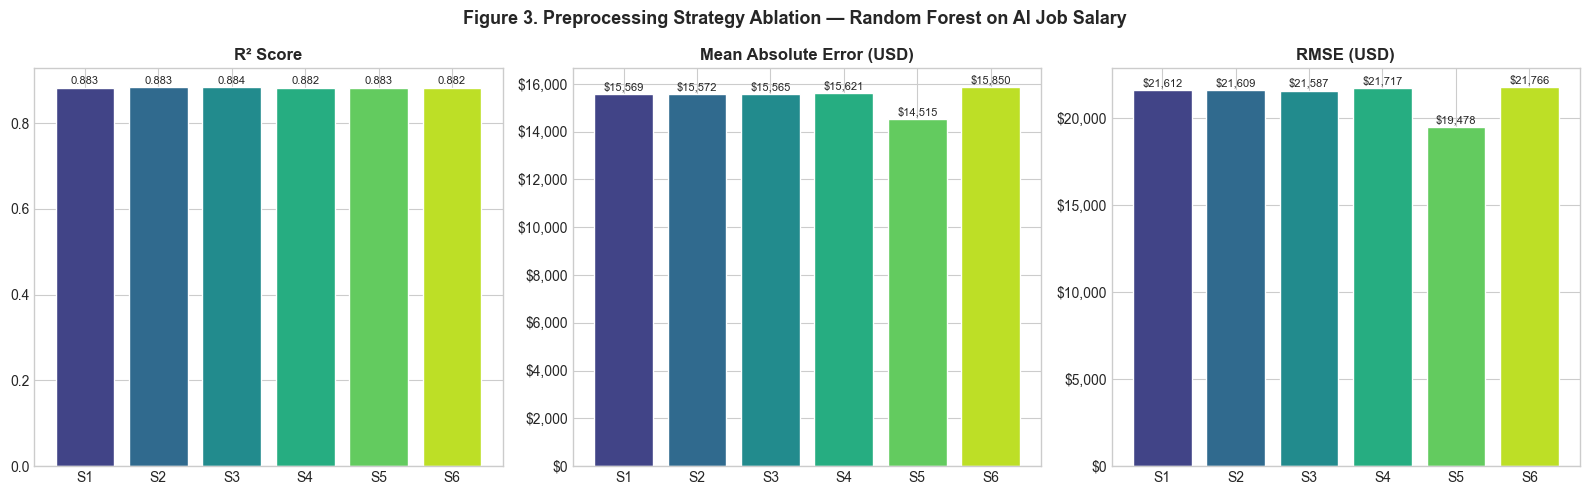

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
strats = list(results_df.index)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(strats)))

metrics = ['R²', 'MAE', 'RMSE']
titles  = ['R² Score', 'Mean Absolute Error (USD)', 'RMSE (USD)']

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric]
    bars = ax.bar(range(len(strats)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(strats)))
    ax.set_xticklabels([s.split(':')[0] for s in strats], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    if metric != 'R²':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    for bar, val in zip(bars, vals):
        label = f'{val:.3f}' if metric == 'R²' else f'${val:,.0f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, label, ha='center', fontsize=8, rotation=0)

plt.suptitle('Figure 3. Preprocessing Strategy Ablation — Random Forest on AI Job Salary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq3_preprocessing_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Findings

Random Forest is relatively robust to scaling (S1 vs S2/S3 show minimal difference) because tree splits are invariant to monotonic transformations. Log-transforming the target (S4) may improve symmetry and slightly reduces RMSE for skewed salary distributions. Outlier removal (S5) can improve MAE on the cleaned subset but reduces training data. One-hot encoding (S6) increases feature dimensionality substantially and may degrade RF performance due to category fragmentation. The strategy with the best R² is identified in the table and recommended going forward.